#Actividad 1
Es importante que realices todas las actividades, estas te permitirán saber como vas avanzando y podrás reflexionar sobre la teoría si te queda alguna duda de cómo hacer esta actividad por favor consultanos en el campus.

El objetivo de esta actividad es encontrar un dataset de tu interés que contenga como variable objetivo una variable continua y aplicar la regresión lineal para intentar predecirla a partir de las demás variables predictoras.

El método que seguiremos es el siguiente:

●      Preparación y organización de datos

●      Exploración de los datos

●      Modelado de datos

### importacion de librerias


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score

### Carga del data set


In [29]:
df = pd.read_csv("propiedades_argentina.csv", engine='python', on_bad_lines='warn')
print('Shape del dataset:', df.shape)
print(df.head())

Shape del dataset: (146660, 19)
   start_date    end_date  created_on        lat        lon         l1  \
0  2019-10-17  2019-12-23  2019-10-17 -34.605880 -58.384949  Argentina   
1  2019-10-17  2019-11-21  2019-10-17 -34.624056 -58.412110  Argentina   
2  2019-10-17  2019-11-01  2019-10-17 -34.593569 -58.427474  Argentina   
3  2019-10-17  2019-12-23  2019-10-17 -34.581294 -58.436754  Argentina   
4  2019-10-17  2020-03-11  2019-10-17 -34.914194 -57.938219  Argentina   

                       l2             l3  rooms  bedrooms  bathrooms  \
0         Capital Federal  San Cristobal    7.0       7.0        2.0   
1         Capital Federal          Boedo    2.0       1.0        2.0   
2         Capital Federal        Palermo    2.0       1.0        1.0   
3         Capital Federal        Palermo    2.0       1.0        1.0   
4  Bs.As. G.B.A. Zona Sur       La Plata    2.0       1.0        1.0   

   surface_total  surface_covered     price currency  \
0          140.0            140.0 

### Exploracion de datos

In [30]:
print('\nInformación general:')
df.info()

print('\nEstadísticas:')
print(df.describe())

print('\nValores nulos:')
print(df.isnull().sum())


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146660 entries, 0 to 146659
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   start_date       146660 non-null  object 
 1   end_date         146660 non-null  object 
 2   created_on       146660 non-null  object 
 3   lat              136735 non-null  float64
 4   lon              136701 non-null  float64
 5   l1               146660 non-null  object 
 6   l2               146660 non-null  object 
 7   l3               146660 non-null  object 
 8   rooms            146660 non-null  float64
 9   bedrooms         146660 non-null  float64
 10  bathrooms        140703 non-null  float64
 11  surface_total    126133 non-null  float64
 12  surface_covered  125046 non-null  float64
 13  price            146660 non-null  float64
 14  currency         146660 non-null  object 
 15  title            146660 non-null  object 
 16  description     

### Limpieza de datos

In [31]:
df = df.dropna(subset=['price', 'surface_total', 'rooms'])

### Visualizaciones


histograma

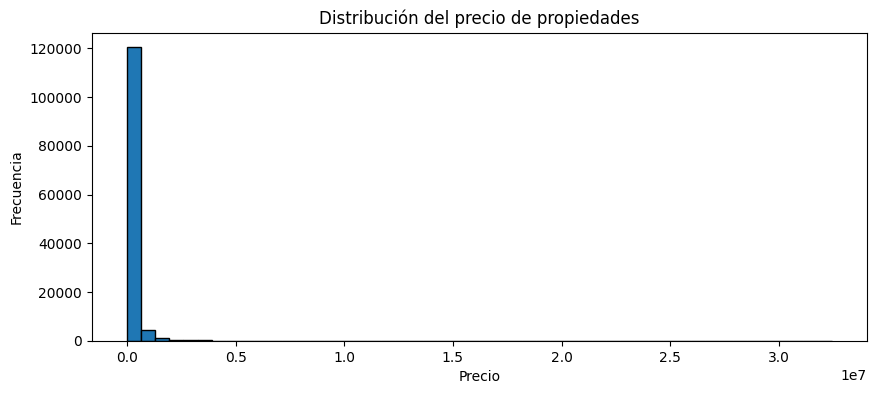

In [32]:
plt.figure(figsize=(10,4))
plt.hist(df['price'], bins=50, edgecolor='black')
plt.title('Distribución del precio de propiedades')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

Scatter plots

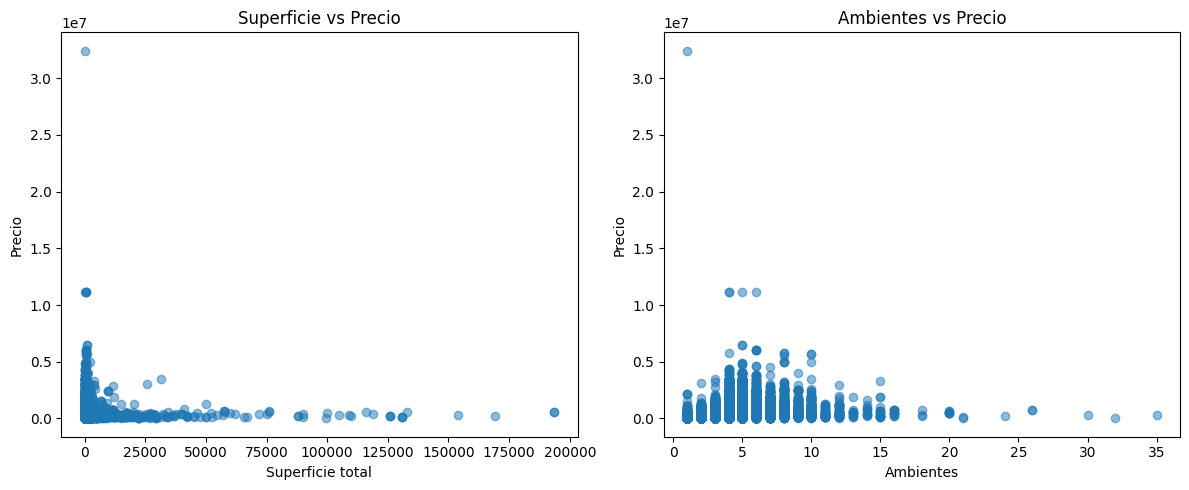

In [33]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(df['surface_total'], df['price'], alpha=0.5)
plt.xlabel('Superficie total')
plt.ylabel('Precio')
plt.title('Superficie vs Precio')

plt.subplot(1,2,2)
plt.scatter(df['rooms'], df['price'], alpha=0.5)
plt.xlabel('Ambientes')
plt.ylabel('Precio')
plt.title('Ambientes vs Precio')

plt.tight_layout()
plt.show()

###Matriz de correlación

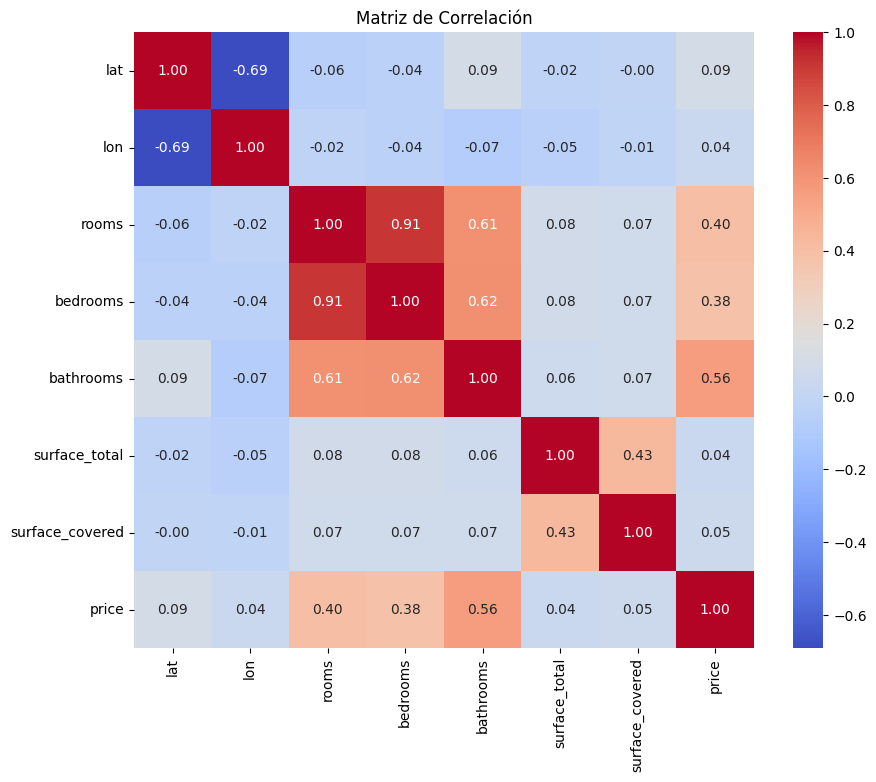

In [34]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

###Preparacion de datos y division de datos para entrenamiento y prueba

In [35]:

# Variables predictoras y objetivo
X = df[['surface_total', 'rooms']]
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Datos de entrenamiento: {len(X_train)}')
print(f'Datos de prueba: {len(X_test)}')

Datos de entrenamiento: 100906
Datos de prueba: 25227


###### Creacion del  modelo de regresión lineal y se entrena utilizando los datos de entrenamiento.

In [36]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nIntercepto:", model.intercept_)
print("Coeficientes:", model.coef_)


Intercepto: -25365.451147418877
Coeficientes: [9.69500093e-01 8.58624846e+04]


### Evalucion

In [37]:
print("\nEvaluación del modelo:")

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"Varianza explicada: {explained_variance_score(y_test, y_pred):.4f}")



Evaluación del modelo:
MAE: 121390.48
MSE: 102605667236.58
R²: 0.1147
Varianza explicada: 0.1147


Visualizacion de resultados

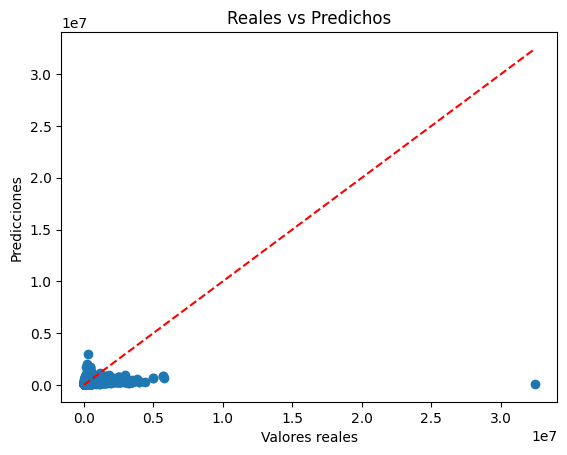

In [38]:
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Reales vs Predichos")
plt.show()

### Residuos

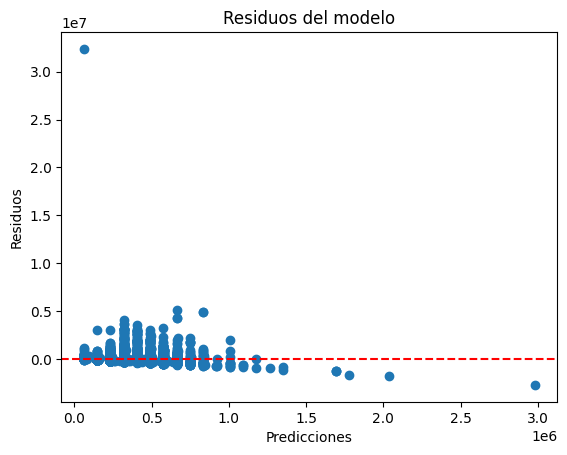

In [39]:
residuos = y_test - y_pred

plt.scatter(y_pred, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos del modelo")
plt.show()

###Coeficientes

In [40]:
coef = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": model.coef_
})

print("\nImportancia de variables:")
print(coef.sort_values(by="Coeficiente", ascending=False))


Importancia de variables:
        Variable   Coeficiente
1          rooms  85862.484642
0  surface_total      0.969500


El modelo de regresión lineal aplicado al dataset de Precios de Propiedades Argentina permitió predecir el precio de las propiedades a partir de variables como la superficie total y la cantidad de ambientes. Los resultados obtenidos muestran un desempeño moderado, donde el modelo logra capturar la tendencia general de que a mayor superficie y mayor cantidad de ambientes, mayor es el precio. Sin embargo, los gráficos de valores reales vs predichos evidencian cierta dispersión, lo que indica que el modelo no logra explicar completamente la variabilidad del precio. Esto se debe a que existen otros factores relevantes, como la ubicación o el tipo de propiedad, que no fueron incluidos en el modelo. En consecuencia, el modelo resulta útil como una primera aproximación, aunque podría mejorarse incorporando más variables explicativas.
